In [2]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [3]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib
import matplotlib.colors as colors
import copy
import cmaps

In [4]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [5]:
rot = False

dycore1 = 'CAM-SE'
dycore2 = 'CAM-FV3, ksplit=4, hord=10'
dycore3 = 'CAM-MPAS'
dycore4 = 'CAM-FV3, ksplit=4, hord=5'

res1 = 'se_ne60'
res2 = 'fv3_C192'
res3 = 'mpasa60'
res4 = 'fv3_C192'

test_name_start1 = 'cam_6_4_100'
test_name_start2 = 'cam_6_4_070_horiz_mount_flow'
test_name_start3 = 'cam_6_4_080_paper_six'
test_name_start4 = 'cam_6_4_070_horiz_mount_flow'

lev_no1 = 'ztop20km_L57'
lev_no2 = 'ztop20km_L57'
lev_no3 = 'L20km_L57'
lev_no4 = 'ztop20km_L57'

extra_name1 = 'tau_1_10'
extra_name2 = 'tau_1_10_no_vortdamp'
extra_name3 = 'tau_1_10_new_vgrid'
extra_name4 = 'tau_1_10_no_vortdamp_ksplit4_hord5'


case1 = f'{test_name_start1}_{res1}_{lev_no1}'
case2 = f'{test_name_start2}_{res2}_{lev_no2}'
case3 = f'{test_name_start3}_{res3}_{lev_no3}'
case4 = f'{test_name_start4}_{res4}_{lev_no4}'


# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name3}'
    nc_file4 = f'{case4}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name4}'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name3}'
    nc_file4 = f'{case4}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name4}'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.regrid.0.5x0.5.nc'  # For FV3.
nc_file3 = nc_file3 + '.regrid.0.5x0.5.nc'
nc_file4 = nc_file4 + '.regrid.0.5x0.5.nc'

In [6]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3
run_path4 = run_base + case4 + '/run/' + nc_file4

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)
nc4 = Dataset(run_path4)

In [7]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

In [8]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
if rot == True:
    lat_crop_up = 50.
    lat_cent_down = -10.
    lat_ticks = np.linspace(0.,40.,3)

    # Test is mountain is between 19 deg and 21 deg N.
    #lat_crop_up = 24.
    #lat_cent_down = 16.
    #lat_ticks=None

    lon_crop_left = 160.
    lon_crop_right = 360.
    lon_ticks = np.linspace(180., 340., 5)
else:
    #lat_crop_up = 50.
    #lat_cent_down = -10.
    #lat_ticks = np.linspace(0,40,3)

    lat_crop_up = 40.
    lat_cent_down = 0.
    lat_ticks = np.linspace(0,40,5)

    lon_crop_left = 160.
    lon_crop_right = 320.
    lon_ticks = np.linspace(180, 300, 4)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

In [9]:
# Time index to compare at
t_idx = 80

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

# Sizes for figures
title_size=16
label_size=14
small_size=12

#Set up the cmap parameters
U_cmap = matplotlib.cm.seismic
#U_cmap.set_under('k')
#U_cmap.set_over('white')

vort_cmap = matplotlib.cm.RdBu_r
#vort_cmap.set_under('k')
#vort_cmap.set_over('white')

T_cmap = matplotlib.cm.jet
#T_cmap.set_under('k')
#T_cmap.set_over('white')

In [10]:
# Interpolations of U, V, T

u1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u4 = z_interp(nc4['Z3'][t_idx, :, lat_inds, lon_inds], nc4['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

v1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v4 = z_interp(nc4['Z3'][t_idx, :, lat_inds, lon_inds], nc4['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T4 = z_interp(nc4['Z3'][t_idx, :, lat_inds, lon_inds], nc4['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [11]:
# Compute relative vorticity:
uv_ds1 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u1), V=(['lat', 'lon'], v1)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds1['U'].attrs["units"] = "m/s"
uv_ds1['V'].attrs["units"] = "m/s"
vort_1 = mpcalc.vorticity(uv_ds1['U'], uv_ds1['V'])

uv_ds2 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u2), V=(['lat', 'lon'], v2)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds2['U'].attrs["units"] = "m/s"
uv_ds2['V'].attrs["units"] = "m/s"
vort_2 = mpcalc.vorticity(uv_ds2['U'], uv_ds2['V'])

uv_ds3 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u3), V=(['lat', 'lon'], v3)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds3['U'].attrs["units"] = "m/s"
uv_ds3['V'].attrs["units"] = "m/s"
vort_3 = mpcalc.vorticity(uv_ds3['U'], uv_ds3['V'])

uv_ds4 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u4), V=(['lat', 'lon'], v4)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds4['U'].attrs["units"] = "m/s"
uv_ds4['V'].attrs["units"] = "m/s"
vort_4 = mpcalc.vorticity(uv_ds4['U'], uv_ds4['V'])

In [12]:
deg2rad = np.pi/180
u0 = 10
T0 = 288

# Normalised velocity perturbation:
U_field_vals1 = (u1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (u2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals3 = (u3 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals4 = (u4 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
# Temperature perturbation:
T_field_vals1 = T1 - T0
T_field_vals2 = T2 - T0
T_field_vals3 = T3 - T0
T_field_vals4 = T4 - T0

min value is -1.7275985147630006
max value is 0.7786868961007782


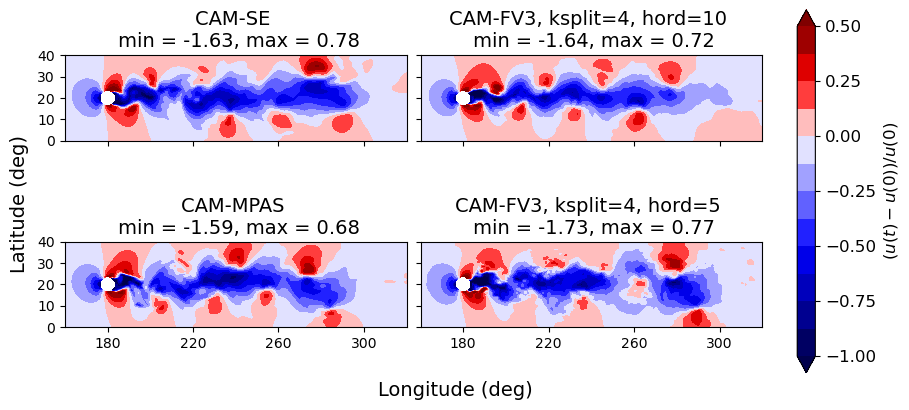

In [13]:
# Plot for U
#U_cmap_choice = 'RdYlBu_r'
U_cmap_choice = 'seismic'

U_max1 = np.nanmax(U_field_vals1)
U_max2 = np.nanmax(U_field_vals2)
U_max3 = np.nanmax(U_field_vals3)
U_max4 = np.nanmax(U_field_vals4)

U_min1 = np.nanmin(U_field_vals1)
U_min2 = np.nanmin(U_field_vals2)
U_min3 = np.nanmin(U_field_vals3)
U_min4 = np.nanmin(U_field_vals4)

U_maxmax = max(U_max1, U_max2, U_max3, U_max4)
U_minmin = min(U_min1, U_min2, U_min3, U_min4)

print('min value is', U_minmin)
print('max value is', U_maxmax)

fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (9,4), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

if rot:
    conts = np.linspace(-0.4, 0.4, 9)
    tick_range = np.linspace(-0.4, 0.4, 5)
    norm = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0, vmax=0.4)
    #conts = np.linspace(-1.5, 1.5, 9)
    #tick_range = np.linspace(-1.5, 1.5, 5)
    #norm = colors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.5)
else:
    conts = np.linspace(-1, 0.5, 13)
    tick_range = np.linspace(-1, 0.5, 7)
    norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=0.5)
plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = conts, cmap=U_cmap_choice, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = conts, cmap=U_cmap_choice, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, U_field_vals3, levels = conts, cmap=U_cmap_choice, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, U_field_vals4, levels = conts, cmap=U_cmap_choice, norm=norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot4, ax=axes, ticks = tick_range, fraction=0.1)
cb.set_label(label='$(u(t) - u(0))/u(0)$', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore1} \n min = {np.round(U_min1,2)}, max = {np.round(U_max1,2)}', size=label_size)
ax2.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
ax3.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)
ax4.set_title(f'{dycore4} \n min = {np.round(U_min4,2)}, max = {np.round(U_max4,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
if rot:
    plt.savefig('figures/vortex_with_rot_U.png')
else:
    plt.savefig('figures/vortex_omega0_U.png')

min value is -2.021734720426366
max value is 6.975605366094385


Text(0.5, 0.01, 'Longitude (deg)')

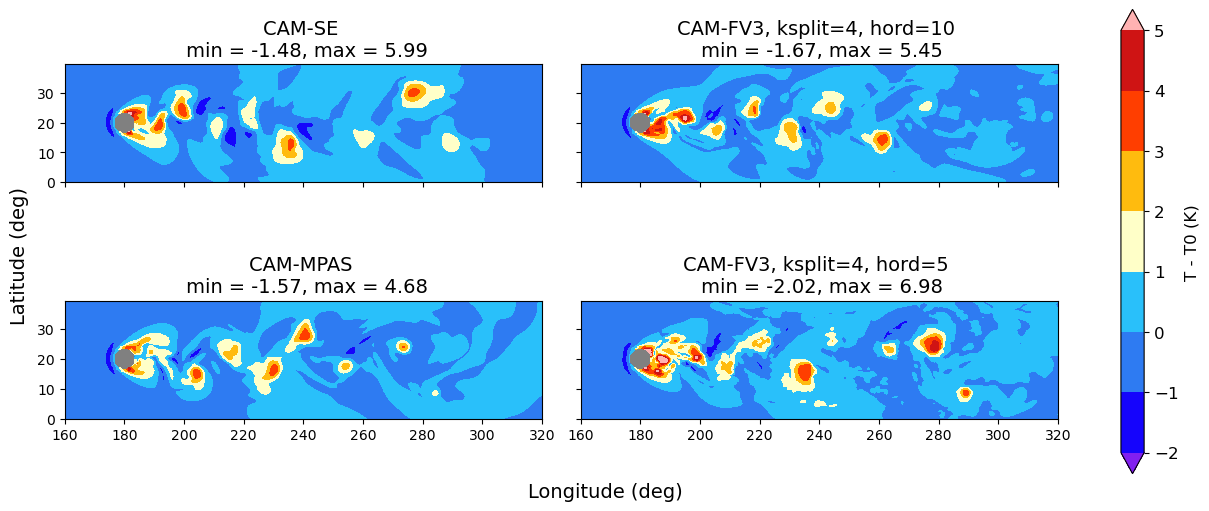

In [14]:
# T plot

#T_cmap = matplotlib.cm.seismic
#T_cmap = copy.copy(matplotlib.cm.jet)
T_cmap = cmaps.ncl_default
#T_cmap.set_under('k')
#T_cmap.set_over('white')

T_max1 = np.nanmax(T_field_vals1)
T_max2 = np.nanmax(T_field_vals2)
T_max3 = np.nanmax(T_field_vals3)
T_max4 = np.nanmax(T_field_vals4)

T_min1 = np.nanmin(T_field_vals1)
T_min2 = np.nanmin(T_field_vals2)
T_min3 = np.nanmin(T_field_vals3)
T_min4 = np.nanmin(T_field_vals4)

T_maxmax = max(T_max1, T_max2, T_max3, T_max4)
T_minmin = min(T_min1, T_min2, T_min3, T_min4)

print('min value is', T_minmin)
print('max value is', T_maxmax)

fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (12,5), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

if rot:
    T_conts = np.linspace(-1, 2, 7)
    #norm = colors.Normalize(vmin=-1, vmax=3)
    norm=None
    tick_range = np.linspace(-1, 2, 7)
else:
    T_conts = np.linspace(-2, 5, 8)
    #norm = colors.Normalize(vmin=-1, vmax=4)
    #norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=4.0)
    norm = None
    tick_range = np.linspace(-2, 5, 8)
plot1 = ax1.contourf(LON, LAT, T_field_vals1, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals2, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, T_field_vals3, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, T_field_vals4, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')

# If we want contours overlaid:
#ax1.contour(LON, LAT, T_field_vals1, levels = T_conts, linestyles='solid', colors='k', linewidths=1, norm=norm, extend = 'both')
#ax2.contour(LON, LAT, T_field_vals2, levels = T_conts, linestyles='solid', colors='k', linewidths=1, norm=norm, extend = 'both')
#ax3.contour(LON, LAT, T_field_vals3, levels = T_conts, linestyles='solid', colors='k', linewidths=1, norm=norm, extend = 'both')
#ax4.contour(LON, LAT, T_field_vals4, levels = T_conts, linestyles='solid', colors='k', linewidths=1, norm=norm, extend = 'both')

T_title = 'Temperature perturbation'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")
ax3.set_facecolor("grey")
ax4.set_facecolor("grey")

cb = plt.colorbar(plot4, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label='T - T0 (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore1} \n min = {np.round(T_min1,2)}, max = {np.round(T_max1,2)}', size=label_size)
ax2.set_title(f'{dycore2} \n min = {np.round(T_min2,2)}, max = {np.round(T_max2,2)}', size=label_size)
ax3.set_title(f'{dycore3} \n min = {np.round(T_min3,2)}, max = {np.round(T_max3,2)}', size=label_size)
ax4.set_title(f'{dycore4} \n min = {np.round(T_min4,2)}, max = {np.round(T_max4,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

min value is -0.0002632572309409127
max value is 0.00020426113270810716


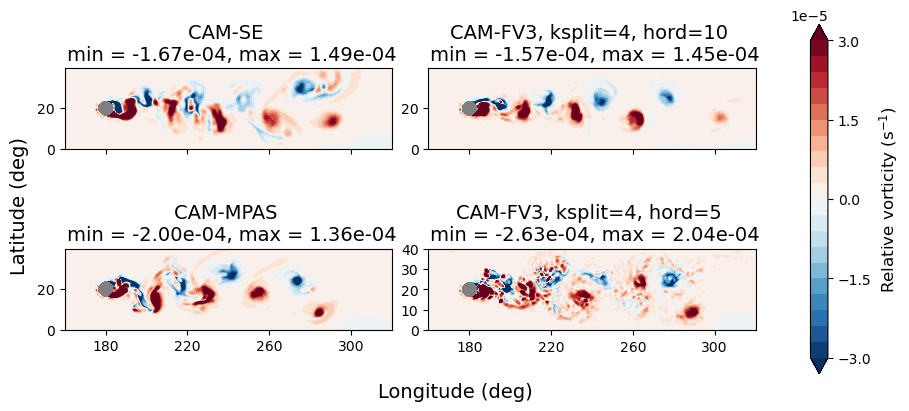

In [15]:
# Plot relative vorticity:

# Saturate to better show the shed vortices, as the vorticity is largest around the mountain

cmap_choice = 'RdBu_r'
#cmap = matplotlib.cm.RdBu_r
#cmap.set_under('k')
#cmap.set_over('white')

vort_max1 = np.nanmax(vort_1)
vort_max2 = np.nanmax(vort_2)
vort_max3 = np.nanmax(vort_3)
vort_max4 = np.nanmax(vort_4)

vort_min1 = np.nanmin(vort_1)
vort_min2 = np.nanmin(vort_2)
vort_min3 = np.nanmin(vort_3)
vort_min4 = np.nanmin(vort_4)

vort_maxmax = max(vort_max1, vort_max2, vort_max3, vort_max4)
vort_minmin = min(vort_min1, vort_min2, vort_min3, vort_min4)
absmax = 3e-5
#absmax = max(abs(minmin),abs(maxmax))

print('min value is', vort_minmin)
print('max value is', vort_maxmax)

conts = np.linspace(-absmax, absmax, 21)
tick_range = np.linspace(-absmax, absmax, 5)
norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

fig, axes = plt.subplots(2,2, sharex=True, figsize = (9,4), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")
ax3.set_facecolor("grey")
ax4.set_facecolor("grey")

plot1 = ax1.contourf(LON, LAT, vort_1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, vort_2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, vort_3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, vort_4, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')

ax1.set_title(f'{dycore1} \n min = {vort_min1:.2e}, max = {vort_max1:.2e}', size=label_size)
ax2.set_title(f'{dycore2} \n min = {vort_min2:.2e}, max = {vort_max2:.2e}', size=label_size)
ax3.set_title(f'{dycore3} \n min = {vort_min3:.2e}, max = {vort_max3:.2e}', size=label_size)
ax4.set_title(f'{dycore4} \n min = {vort_min4:.2e}, max = {vort_max4:.2e}', size=label_size)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot4, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label='Relative vorticity (s$^{-1}$)', size=small_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
if rot:
    plt.savefig('figures/vortex_with_rot_vort.png')
else:
    plt.savefig('figures/vortex_omega0_vort.png')

In [16]:
#Lat vert cross sections:
p0 = 1e5
Rd = 287.04
g = 9.80616
H = Rd*T0/g

lon = nc1['lon'][:] 
lat = nc1['lat'][:] 

lev1 = nc1['lev'][:] 
lev2 = nc2['lev'][:]

# MPAS lev is pressure, so convert to z:
mpas_ps = nc3['PS'][:]
mpas_z = nc3['lev'][:]
lev3 = 0.01*p0*np.exp(-mpas_z/H)

lon_crop_left = 150
lon_crop_right = 300

# User parameters:
t_idx = -1
field = 'W'

lon_ticks = np.linspace(lon_crop_left, lon_crop_right, 5)

lon_crop_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))
lon_crop = lon[lon_crop_inds]

LONGC1, P1 = np.meshgrid(lon_crop, lev1) 
LONGC2, P2 = np.meshgrid(lon_crop, lev2) 
LONGC3, P3 = np.meshgrid(lon_crop, lev3) 

# Pick the latitude to slice at:
lat_val = 220

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)


if field=='W':
    Rd = 287.04
    g = 9.80616
    # Convert P from hPa to Pa
    field1 = (Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P1*100)
    field2 = (Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P2*100)
    field3 = (Rd/g)*nc3['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc3['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P3*100)
else:
    field1 = nc1[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field2 = nc2[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field3 = nc3[field][t_idx, :, lat_val, lon_crop_inds[0]]

ps_t = nc1['PS'][t_idx, lat_val, lon_crop_inds[0]]/100

cmap_choice = 'coolwarm'

lat in deg is 20.0


Text(0.5, 1.0, 'CAM-MPAS \n \n min = -0.603 m/s \n max = 0.699 m/s')

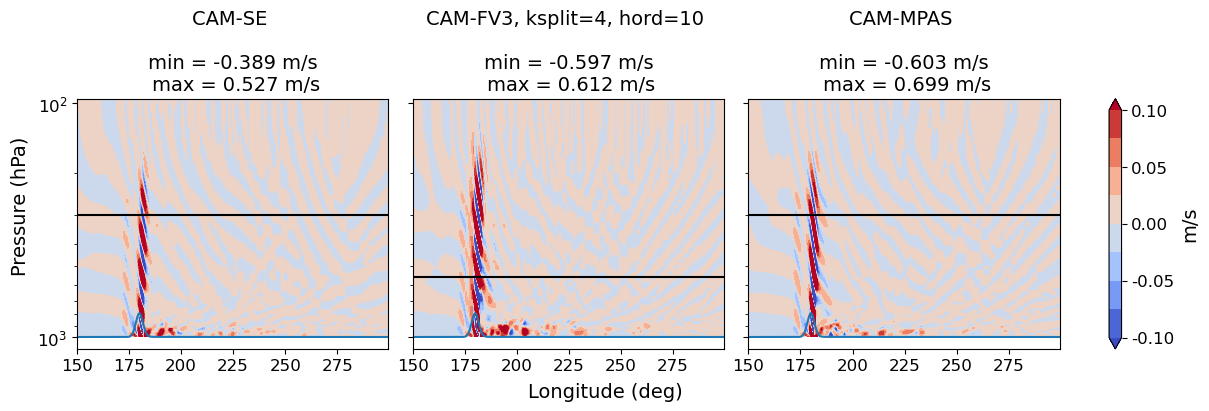

In [17]:
max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1
absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)
plot1 = ax1.contourf(LONGC1, P1, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC2, P2, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC3, P3, field3, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

cb = plt.colorbar(plot3,ax=axes,pad=0.05,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label('m/s', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82
pc_low =552.4

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc_low*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

ax1.set_title(f'{dycore1} \n \n min = {min1:.3f} m/s \n max = {max1:.3f} m/s', size=label_size)
ax2.set_title(f'{dycore2} \n \n min = {min2:.3f} m/s \n max = {max2:.3f} m/s', size=label_size)
ax3.set_title(f'{dycore3} \n \n min = {min3:.3f} m/s \n max = {max3:.3f} m/s', size=label_size)

Text(0.5, 0.01, 'Longitude (deg)')

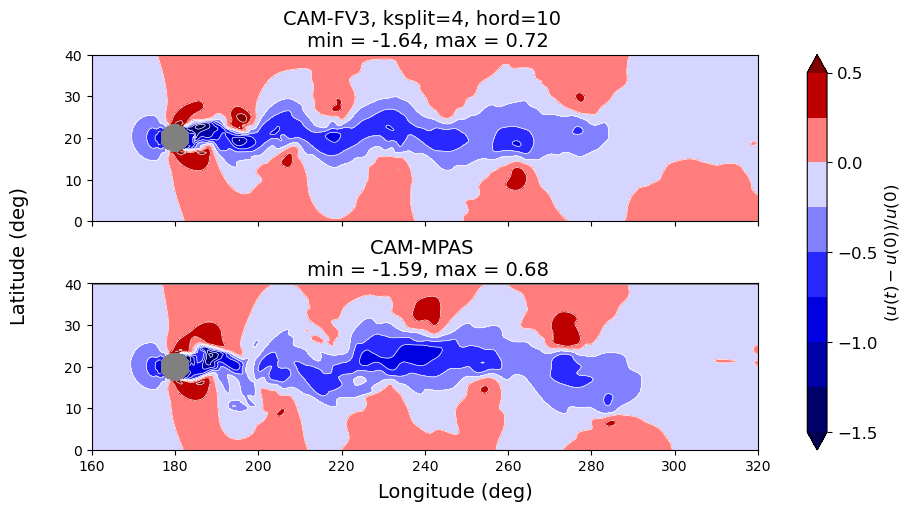

In [18]:
# Just FV3 and MPAS for Christiane's poster
# Compare U fields

fig, axes = plt.subplots(2,1, sharex=True, sharey=True, figsize = (9,5), layout="constrained")
(ax1, ax2) = axes

if rot:
    conts = np.linspace(-2.0, 2.0, 9)
    tick_range = np.linspace(-2.0, 2.0, 9)
    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
else:
    conts = np.linspace(-1.5, 0.5, 9)
    tick_range = np.linspace(-1.5, 0.5, 5)
    norm = colors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=0.5)
    
plot1 = ax1.contour(LON, LAT, U_field_vals2, levels = conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
plot2 = ax2.contour(LON, LAT, U_field_vals3, levels = conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
plot1 = ax1.contourf(LON, LAT, U_field_vals2, levels = conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals3, levels = conts, cmap=U_cmap, norm=norm, extend = 'both')

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.ylim([-0,40])

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, fraction=0.15)
cb.set_label(label='$(u(t) - u(0))/u(0)$', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
ax2.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

Text(0.5, 0.01, 'Longitude (deg)')

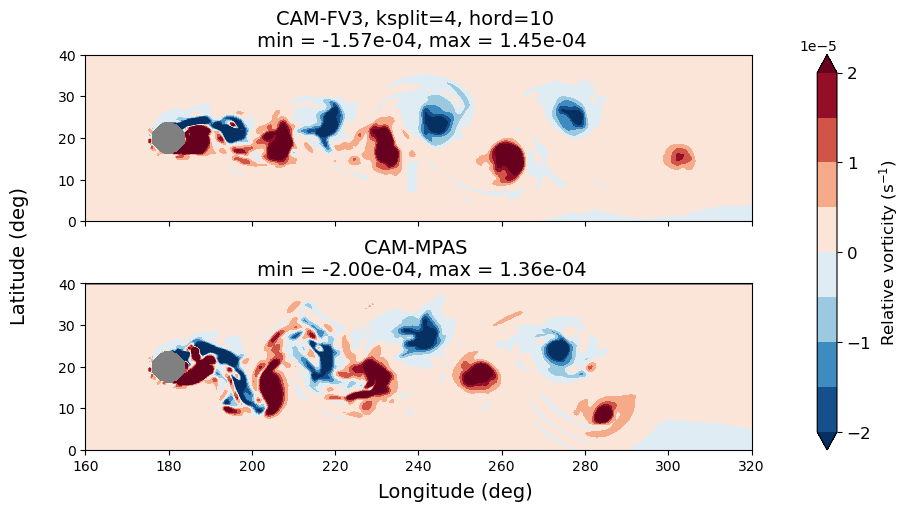

In [19]:
# Just FV3 and MPAS for Christiane's poster
# Compare vorticity fields

fig, axes = plt.subplots(2,1, sharex=True, sharey=True, figsize = (9,5), layout="constrained")
(ax1, ax2) = axes

vort_max = 2e-5
vort_min = -2e-5

conts = np.linspace(vort_min, vort_max, 9)
tick_range = np.linspace(vort_min, vort_max, 5)
norm = colors.TwoSlopeNorm(vmin=vort_min, vcenter=0, vmax=vort_max)
    
#plot1 = ax1.contour(LON, LAT, vort_2, levels = conts, linestyles='solid', colors='white', linewidths=1, norm=norm, extend = 'both')
#plot2 = ax2.contour(LON, LAT, vort_3, levels = conts, linestyles='solid', colors='white', linewidths=1, norm=norm, extend = 'both')
plot1 = ax1.contourf(LON, LAT, vort_2, levels = conts, cmap=vort_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, vort_3, levels = conts, cmap=vort_cmap, norm=norm, extend = 'both')

plt.ylim([0,40])

ax1.set_aspect('equal')
ax2.set_aspect('equal')

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, fraction=0.15)
cb.set_label(label='Relative vorticity (s$^{-1}$)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore2} \n min = {vort_min2:.2e}, max = {vort_max2:.2e}', size=label_size)
ax2.set_title(f'{dycore3} \n min = {vort_min3:.2e}, max = {vort_max3:.2e}', size=label_size)

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

Text(0.5, 0.01, 'Longitude (deg)')

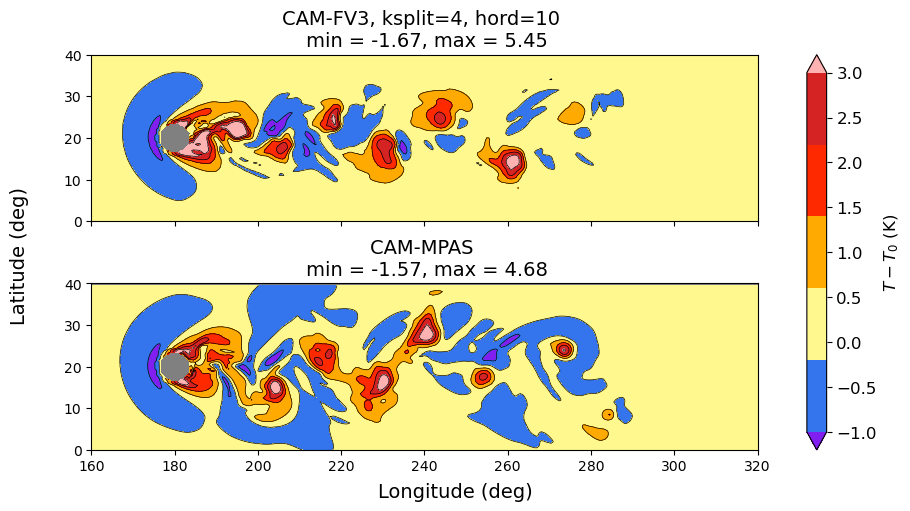

In [20]:
# Just FV3 and MPAS for Christiane's poster
fig, axes = plt.subplots(2,1, sharex=True, sharey=True, figsize = (9,5), layout="constrained")
(ax1, ax2) = axes

T_max1 = np.nanmax(T_field_vals1)
T_max2 = np.nanmax(T_field_vals2)
T_max3 = np.nanmax(T_field_vals3)
T_max4 = np.nanmax(T_field_vals4)

T_min1 = np.nanmin(T_field_vals1)
T_min2 = np.nanmin(T_field_vals2)
T_min3 = np.nanmin(T_field_vals3)
T_min4 = np.nanmin(T_field_vals4)

if rot:
    conts = np.linspace(-1, 5, 7)
    norm = colors.Normalize(vmin=-1, vmax=5)
    tick_range = np.linspace(-1, 5, 7)
else:
    conts = np.linspace(-1, 3, 6)
    norm = colors.TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=3.0)
    tick_range = np.linspace(-1, 3, 9)

plot1 = ax1.contour(LON, LAT, T_field_vals2, levels = conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
plot2 = ax2.contour(LON, LAT, T_field_vals3, levels = conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
plot1 = ax1.contourf(LON, LAT, T_field_vals2, levels = conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals3, levels = conts, cmap=T_cmap, norm=norm, extend = 'both')

plt.ylim([0,40])

ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, fraction=0.15)
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore2} \n min = {np.round(T_min2,2)}, max = {np.round(T_max2,2)}', size=label_size)
ax2.set_title(f'{dycore3} \n min = {np.round(T_min3,2)}, max = {np.round(T_max3,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)